In [1]:
import sys
sys.path.append('../../../../src')
sys.path.append('../../../..')

import os

from PIL import ImageFont
import matplotlib.pyplot as plt
import numpy as np
from palette.symbol2value import get_asciis
from converters.tile.nearest import Tile2SymbNearest
from image.processing import DITHER_MODES

from tests.experimental.test_loop import Params, test_loop

SYMBOLS = get_asciis()
FONT_PATH = "../../../../fonts/FiraCode-Regular.ttf"
FONT_SIZE = 10
MAX_WIDTH = 30
MAX_HEIGHT = 9
IMG_SET_PATH = "../../../../imgs/BSDS500"
IMG_PATHS = [os.path.join(IMG_SET_PATH, img_name)
             for img_name in os.listdir(IMG_SET_PATH)[:10]]


def make_converter(params: Params):
    return Tile2SymbNearest(
        symbols=SYMBOLS,
        font=ImageFont.truetype(params.font_path, params.font_size),
        **params.converter_args)

In [ ]:
# val_wh

params_space = [
    (w, w * 2) for w in range(1, 5, 1)
]

params_space = list(
    map(lambda val_wh: Params(
        win_width=val_wh[0],
        max_width=MAX_WIDTH,
        max_height=MAX_HEIGHT,
        font_path=FONT_PATH,
        font_size=FONT_SIZE,
        converter_args={'val_wh': val_wh},
        preprocess_args={'quantize_colors': 2,
                         'dither': DITHER_MODES.FS}),
        params_space))

similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=[param.converter_args['val_wh'] for param in params_space])
plt.show()

Min: 0.0909 | Max: 0.3472 | Mean: 0.2280 | Std: 0.0813
Min: 0.0941 | Max: 0.3392 | Mean: 0.2100 | Std: 0.0800
Min: 0.0877 | Max: 0.3249 | Mean: 0.1871 | Std: 0.0759
Min: 0.0832 | Max: 0.3093 | Mean: 0.1692 | Std: 0.0727
Min: 0.0722 | Max: 0.2878 | Mean: 0.1524 | Std: 0.0678


C:\Users\wojte\AppData\Local\Temp\ipykernel_9356\113247016.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


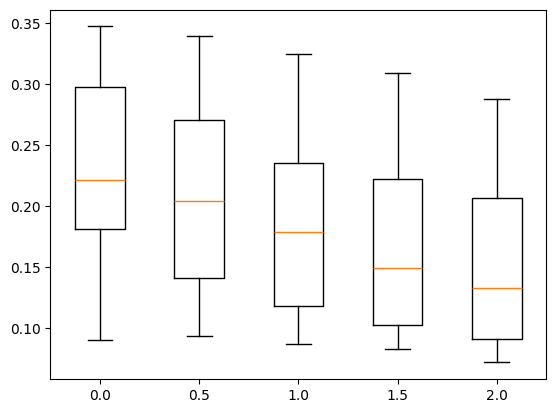

In [ ]:
# edge enhancement

edge_enhancement_vals = [
    e for e in np.linspace(0.0, 2.0, 5, endpoint=True)
]

params_space = list(
    map(lambda e: Params(
        win_width=3,
        max_width=MAX_WIDTH,
        max_height=MAX_HEIGHT,
        font_path=FONT_PATH,
        font_size=FONT_SIZE,
        converter_args={},
        preprocess_args={'quantize_colors': 2,
                         'dither': DITHER_MODES.NONE,
                         'enhance_edges': e}),
        edge_enhancement_vals))

similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=[e for e in edge_enhancement_vals])
plt.show()

Min: 0.0909 | Max: 0.3472 | Mean: 0.2280 | Std: 0.0813
Min: 0.1219 | Max: 0.3411 | Mean: 0.1995 | Std: 0.0533
Min: 0.0719 | Max: 0.2862 | Mean: 0.1633 | Std: 0.0558
Min: 0.0396 | Max: 0.2592 | Mean: 0.1515 | Std: 0.0562
Min: 0.0166 | Max: 0.2395 | Mean: 0.1478 | Std: 0.0621


C:\Users\wojte\AppData\Local\Temp\ipykernel_13916\1339593901.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


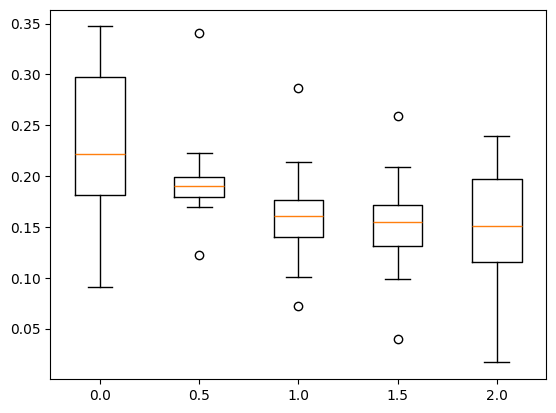

In [2]:
# edge detection

find_edges_vals = [
    e for e in np.linspace(0.0, 2.0, 5, endpoint=True)
]

params_space = list(
    map(lambda e: Params(
        win_width=3,
        max_width=MAX_WIDTH,
        max_height=MAX_HEIGHT,
        font_path=FONT_PATH,
        font_size=FONT_SIZE,
        converter_args={},
        preprocess_args={'quantize_colors': 2,
                         'dither': DITHER_MODES.NONE,
                         'find_edges': e}),
        find_edges_vals))

similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=[e for e in find_edges_vals])
plt.show()

In [3]:
import math
from PIL import Image
from image.processing import preprocess_img
from rendering.terminal import print_gallery


converter = Tile2SymbNearest(symbols=SYMBOLS,
                           font=ImageFont.truetype(FONT_PATH, FONT_SIZE))

results = []
for img_path in IMG_PATHS[:5]:
    img = Image.open(img_path).convert("L")
    img = preprocess_img(img,
                         enhance_edges=0.2,
                         find_edges=1.0,
                         quantize_colors=2, dither=DITHER_MODES.FS)
    win_w = 3
    win_h = win_w * 2
    if MAX_WIDTH:
        scale_w = MAX_WIDTH * win_w / img.width
    if MAX_HEIGHT:
        scale_h = MAX_HEIGHT * win_h / img.height
    img = preprocess_img(img, scale_factor=min(scale_h, scale_w))
    res_arr = converter.process_image(img, (win_w, win_h))
    results.append(res_arr)

print_gallery(results, 2)

d:\CS Projects\python-playground\python-ascii-art\tests\experimental\binarized\tile\../../../../src\converters\tile\nearest.py:39: UserWarning: It is recommended to use mode = grid-constant instead of constant when grid_mode is True.
  tile = zoom(tile, zoom_factors, order=0, grid_mode=True)


---------------------------------------------------------------
 |       `` ~   `            ~ | ~))`{{898{8~~~~~``    ~` -- | 
 |          `       ~~ ~    ~  | ~{)` j89Q9{~`~`~~~~ ~~~`~`` | 
 |                           ~ | ~`` ~{9888{~~`~  ``    `  ~ | 
 |      ```  `           `   ~ | :`  ~]Q8{`"=```~`       ` ~ | 
 |       ~`    `~   `        ~ |      ]{8Q{t`~~~~~   ~~  ``~ | 
 | ~~ ~~~~`~~~~~~~~~`^~~~~~=~~ | ~;~  ]Q888Q{~~~`~~`~`~~~~`~ | 
 | __~__~...~~~~~~~~~~~~~~=~~s | ){s~ j9{Q{Q[~`~~~`~`~~~t~~~ | 
 | {{{{93"f""""~^f{)st)ssf"~`~ | {{9{{98{{Q8{~~~~)~~){~{~~~{ | 
 | {{{_~~~~` `` ``~`~~~~   ~~~ | 9{{{{{Q88QQtts{{s)j{{){{{{{ | 
---------------------------------------------------------------
 |  ~``~ ~   ~~~-~.-~-~~~``    |              | 
 |     `     ~~  ~~~           |              | 
 |                             |              | 
 |  ` ~~)~~~~{){~~~~~~ {{)~="~ |     .  -     | 
 | ``~~~^9s{{{{){{t))~s~~`~)~~ |     )"`~     | 
 | `~~~~`~  `"{t~~~~~~~~~~``   |     ~~`~`    | 
 |